# HCMYO-A Preprocessing for Training

This notebook rebuilds `dataset_analys/hcmyo_preprocessed.npz` for the new HCMYO-A pipeline.

Current preprocessing rules:

- bandpass `1.5..99 Hz` on native `fs=200`
- notch `50 Hz`
- zero padding `150 ms` on both sides
- only `resample_poly` for `200 -> 1000`
- no final FFT resample
- only `center crop / zero pad` to `TARGET_LEN`
- save `lens` so training code can build masks

Saved arrays:

- `X`: `(n_subjects, n_trials, n_channels, n_timepoints)`
- `y`: labels `0..9`
- `subjects`: subject ids
- `sfreq`: final sampling rate
- `lens`: real valid lengths inside each fixed window


In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, resample_poly, welch

# resolve project dirs for outputs
NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / 'preprocessing.ipynb').exists():
    alt = NOTEBOOK_DIR / 'data' / 'preprocessing'
    if (alt / 'preprocessing.ipynb').exists():
        NOTEBOOK_DIR = alt
DATA_ROOT = (NOTEBOOK_DIR / '..').resolve()
PROJECT_ROOT = DATA_ROOT.parent

# --- project-relative raw path ---
DATA_DIR = (DATA_ROOT / 'raw' / 'HCMYO-A' / 'data').resolve()

FS_ORIG = 200
FS_DECLARED = 1000
UP = FS_DECLARED // FS_ORIG

STEP_BACK_MS = 150
STEP_FORWARD_MS = 150
TARGET_PERCENTILE = 80
TARGET_EXTRA = 150

step_back = round(STEP_BACK_MS * FS_ORIG / 1000)
step_forward = round(STEP_FORWARD_MS * FS_ORIG / 1000)

print(f"DATA_DIR = {DATA_DIR} | exists: {DATA_DIR.exists()}")
print(f"native fs = {FS_ORIG} Hz, declared fs = {FS_DECLARED} Hz, up = {UP}")
print(f"step_back = {STEP_BACK_MS} ms = {step_back} samples @ {FS_ORIG} Hz = {step_back * UP} samples @ {FS_DECLARED} Hz")
print(f"step_forward = {STEP_FORWARD_MS} ms = {step_forward} samples @ {FS_ORIG} Hz = {step_forward * UP} samples @ {FS_DECLARED} Hz")


DATA_DIR = Demin/HCMYO-A/data | exists: True
native fs = 200 Hz, declared fs = 1000 Hz, up = 5
step_back = 150 ms = 30 samples @ 200 Hz = 150 samples @ 1000 Hz
step_forward = 150 ms = 30 samples @ 200 Hz = 150 samples @ 1000 Hz
TARGET_LEN rule: q80 + 150 samples @ 1000 Hz


## 1. Load HCMYO-A and compute `TARGET_LEN`

Data layout: `HCMYO-A/data/S0X/<class>/s_quat_*.txt` with 9 CSV columns.
We use only digit classes `0..9` and keep the first 8 EMG channels.

Target window length is computed as:

$$\text{q80\_len} = (p_{80} + \text{step\_back} + \text{step\_forward}) \cdot \text{UP}$$

$$\text{TARGET\_LEN} = \text{q80\_len} + 150$$


In [4]:
def load_hcmyo(data_dir):
    X, y, subj = [], [], []
    for sd in sorted(p for p in data_dir.iterdir() if p.is_dir()):
        for cd in sorted(p for p in sd.iterdir() if p.is_dir()):
            if not cd.name.isdigit():
                continue
            for f in sorted(cd.glob("s_quat_*.txt")):
                arr = np.loadtxt(f, delimiter=",")
                X.append(arr[:, :8].astype(np.float32))
                y.append(int(cd.name))
                subj.append(sd.name)
    return X, np.asarray(y, dtype=int), np.asarray(subj)


X_raw, y_raw, subj_raw = load_hcmyo(DATA_DIR)

lens = np.array([len(x) for x in X_raw])
p_native = int(np.percentile(lens, TARGET_PERCENTILE))
chunk_native = p_native + step_back + step_forward
q80_len = chunk_native * UP
TARGET_LEN = q80_len + TARGET_EXTRA

print(f"total trials: {len(X_raw)}")
print(f"trial lengths @ {FS_ORIG} Hz: min={lens.min()}, max={lens.max()}, mean={lens.mean():.1f}, median={np.median(lens):.0f}, p{TARGET_PERCENTILE}={p_native}")
print()
print("target length computation:")
print(f"  p{TARGET_PERCENTILE} @ {FS_ORIG} Hz = {p_native}")
print(f"  + step_back = {step_back}")
print(f"  + step_forward = {step_forward}")
print(f"  chunk @ {FS_ORIG} Hz = {chunk_native}")
print(f"  x up ({UP}) = {q80_len} samples @ {FS_DECLARED} Hz")
print(f"  + TARGET_EXTRA = {TARGET_EXTRA} samples")
print(f"TARGET_LEN = {TARGET_LEN} samples @ {FS_DECLARED} Hz")
print()
print(f"subjects: {np.unique(subj_raw)}")
print(f"classes: {np.unique(y_raw)}")
vals, cnts = np.unique(subj_raw, return_counts=True)
print(f"per-subject: {dict(zip(vals.tolist(), cnts.tolist()))}")


total trials: 30048
trial lengths @ 200 Hz: min=42, max=984, mean=161.1, median=128, p80=228

target length computation:
  p80 @ 200 Hz = 228
  + step_back = 30
  + step_forward = 30
  chunk @ 200 Hz = 288
  x up (5) = 1440 samples @ 1000 Hz
  + TARGET_EXTRA = 150 samples
TARGET_LEN = 1590 samples @ 1000 Hz

subjects: ['S01' 'S02' 'S03']
classes: [0 1 2 3 4 5 6 7 8 9]
per-subject: {'S01': 10027, 'S02': 10021, 'S03': 10000}


## 2. Bandpass on native `fs=200`

We apply a 4th-order Butterworth bandpass with `1.5..99 Hz`.
The high cutoff is clamped to `min(99, nyquist - 1)`.


trial #0: class=0, subject=S01, len=272
bandpass: 1.5 .. 99.0 Hz @ 200 Hz


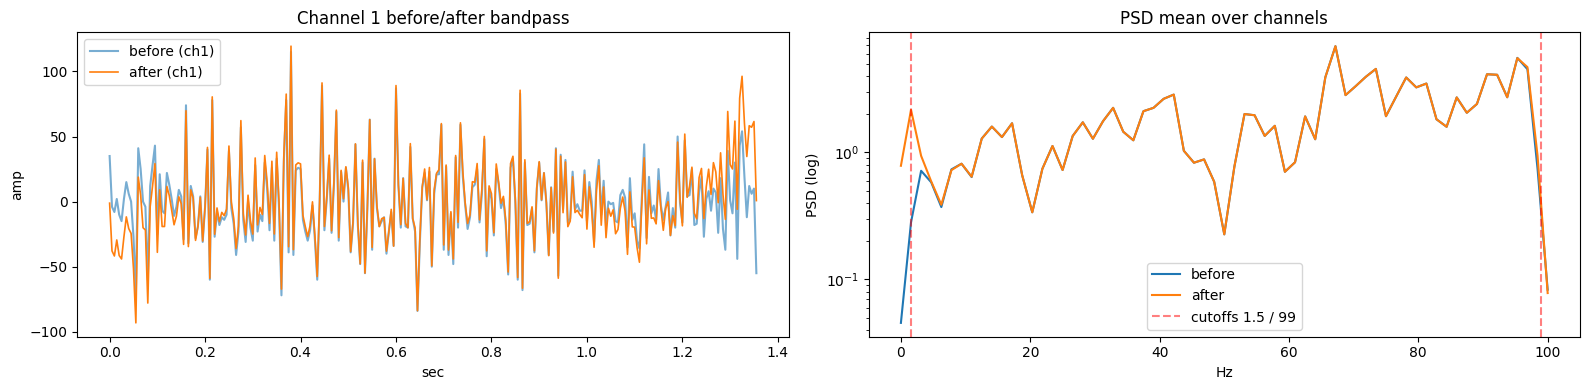

In [5]:
def bandpass(emg, fs, low=1.5, order=4):
    nyq = 0.5 * fs
    high = min(99.0, nyq - 1)
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, emg, axis=0)


DEMO_IDX = 0
demo_raw = X_raw[DEMO_IDX]
demo_bp = bandpass(demo_raw, fs=FS_ORIG)

high_cut = min(99.0, FS_ORIG / 2 - 1)
print(f"trial #{DEMO_IDX}: class={y_raw[DEMO_IDX]}, subject={subj_raw[DEMO_IDX]}, len={len(demo_raw)}")
print(f"bandpass: 1.5 .. {high_cut} Hz @ {FS_ORIG} Hz")

freqs_b, psd_b = welch(demo_raw, fs=FS_ORIG, axis=0, nperseg=min(128, len(demo_raw)))
freqs_a, psd_a = welch(demo_bp, fs=FS_ORIG, axis=0, nperseg=min(128, len(demo_bp)))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
t = np.arange(len(demo_raw)) / FS_ORIG
axes[0].plot(t, demo_raw[:, 0], label="before (ch1)", alpha=0.6)
axes[0].plot(t, demo_bp[:, 0], label="after (ch1)", linewidth=1.2)
axes[0].set_title("Channel 1 before/after bandpass")
axes[0].set_xlabel("sec")
axes[0].set_ylabel("amp")
axes[0].legend()
axes[1].semilogy(freqs_b, psd_b.mean(axis=1), label="before")
axes[1].semilogy(freqs_a, psd_a.mean(axis=1), label="after")
axes[1].axvline(1.5, color="red", ls="--", alpha=0.5)
axes[1].axvline(high_cut, color="red", ls="--", alpha=0.5, label=f"cutoffs 1.5 / {high_cut:.0f}")
axes[1].set_title("PSD mean over channels")
axes[1].set_xlabel("Hz")
axes[1].set_ylabel("PSD (log)")
axes[1].legend()
plt.tight_layout()


## 3. Notch 50 Hz on native `fs=200`


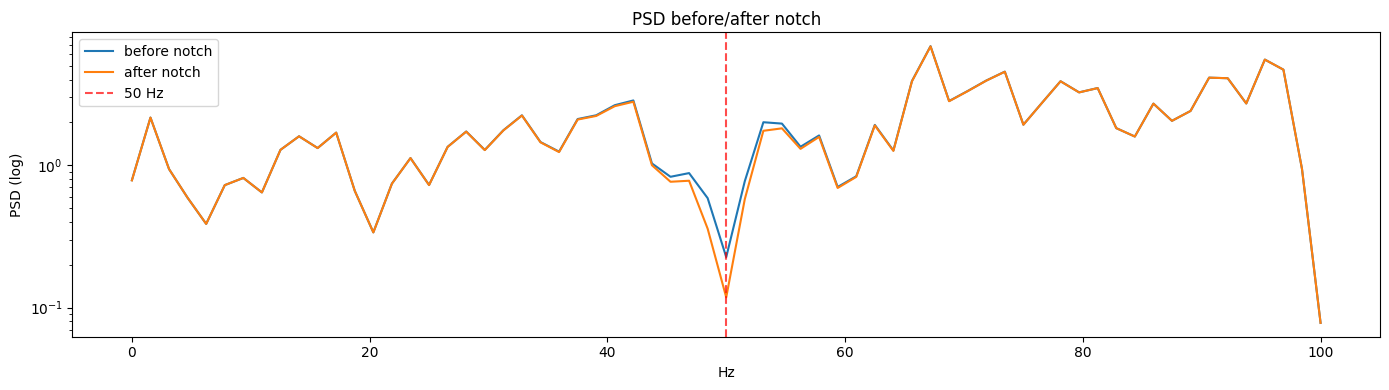

In [6]:
def notch(emg, fs, f0=50.0, Q=30.0):
    nyq = 0.5 * fs
    b, a = iirnotch(f0 / nyq, Q)
    return filtfilt(b, a, emg, axis=0)


demo_nf = notch(demo_bp, fs=FS_ORIG)

freqs_b, psd_b = welch(demo_bp, fs=FS_ORIG, axis=0, nperseg=min(128, len(demo_bp)))
freqs_a, psd_a = welch(demo_nf, fs=FS_ORIG, axis=0, nperseg=min(128, len(demo_nf)))

plt.figure(figsize=(14, 4))
plt.semilogy(freqs_b, psd_b.mean(axis=1), label="before notch")
plt.semilogy(freqs_a, psd_a.mean(axis=1), label="after notch")
plt.axvline(50, color="red", ls="--", alpha=0.7, label="50 Hz")
plt.title("PSD before/after notch")
plt.xlabel("Hz")
plt.ylabel("PSD (log)")
plt.legend()
plt.tight_layout()


## 4. Add zero padding buffers

We pad with zeros by `step_back` and `step_forward` before upsampling.


before pad: shape=(272, 8) len=272
after pad:  shape=(332, 8) len=332 = 272 + 30 + 30


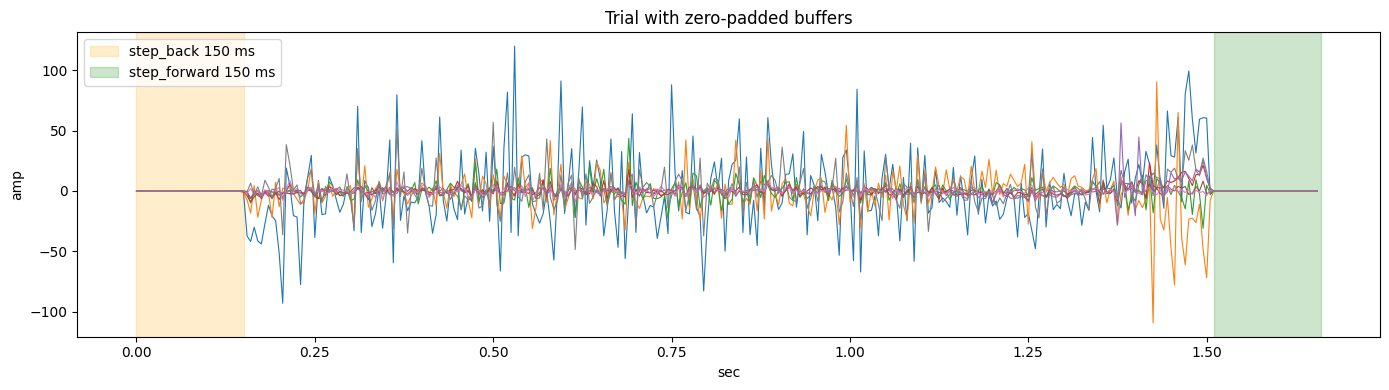

In [7]:
def pad_buffer(emg, step_back, step_forward):
    return np.pad(emg, ((step_back, step_forward), (0, 0)), mode="constant")


demo_pad = pad_buffer(demo_nf, step_back, step_forward)

print(f"before pad: shape={demo_nf.shape} len={len(demo_nf)}")
print(f"after pad:  shape={demo_pad.shape} len={len(demo_pad)} = {len(demo_nf)} + {step_back} + {step_forward}")

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(len(demo_pad)) / FS_ORIG
ax.plot(t, demo_pad, linewidth=0.8)
ax.axvspan(0, step_back / FS_ORIG, color="orange", alpha=0.2, label=f"step_back {STEP_BACK_MS} ms")
ax.axvspan((step_back + len(demo_nf)) / FS_ORIG, len(demo_pad) / FS_ORIG, color="green", alpha=0.2, label=f"step_forward {STEP_FORWARD_MS} ms")
ax.set_title("Trial with zero-padded buffers")
ax.set_xlabel("sec")
ax.set_ylabel("amp")
ax.legend()
plt.tight_layout()


## 5. Upsampling `200 -> 1000`

This step uses `scipy.signal.resample_poly` only.
Duration in seconds stays the same, the sample count grows by `5x`.


before upsample: shape=(332, 8) len=332 @ 200 Hz = 1.660 sec
after upsample:  shape=(1660, 8) len=1660 @ 1000 Hz = 1.660 sec
duration is unchanged, sample count is 5x larger


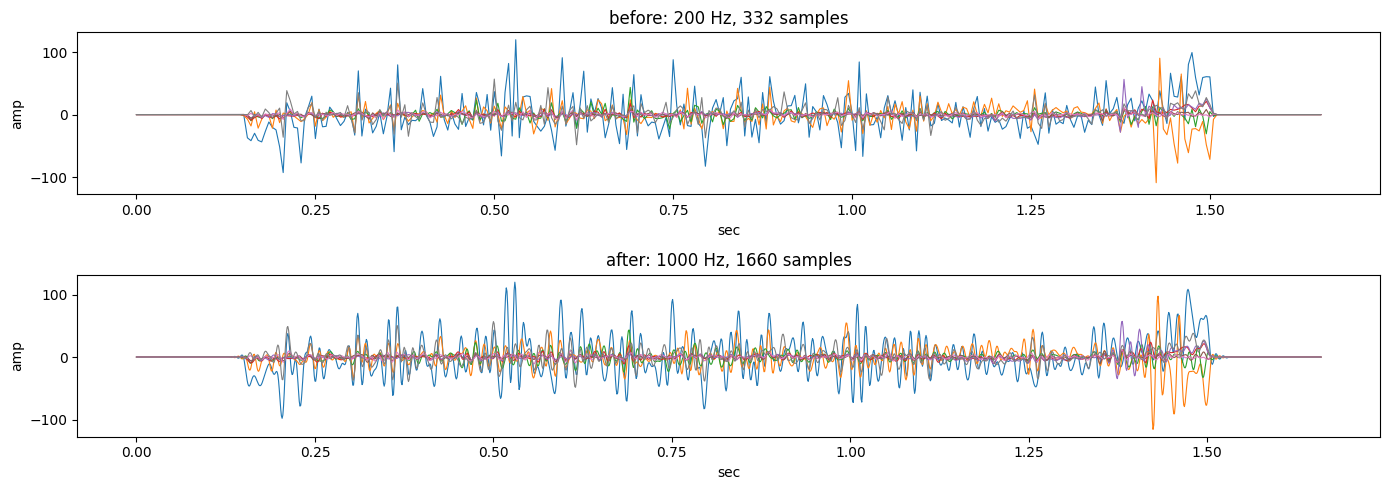

In [8]:
demo_up = resample_poly(demo_pad, up=UP, down=1, axis=0)

print(f"before upsample: shape={demo_pad.shape} len={len(demo_pad)} @ {FS_ORIG} Hz = {len(demo_pad) / FS_ORIG:.3f} sec")
print(f"after upsample:  shape={demo_up.shape} len={len(demo_up)} @ {FS_DECLARED} Hz = {len(demo_up) / FS_DECLARED:.3f} sec")
print(f"duration is unchanged, sample count is {UP}x larger")

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharey=True)
axes[0].plot(np.arange(len(demo_pad)) / FS_ORIG, demo_pad, linewidth=0.8)
axes[0].set_title(f"before: {FS_ORIG} Hz, {len(demo_pad)} samples")
axes[0].set_xlabel("sec")
axes[0].set_ylabel("amp")
axes[1].plot(np.arange(len(demo_up)) / FS_DECLARED, demo_up, linewidth=0.8)
axes[1].set_title(f"after: {FS_DECLARED} Hz, {len(demo_up)} samples")
axes[1].set_xlabel("sec")
axes[1].set_ylabel("amp")
plt.tight_layout()


## 6. Crop or pad to `TARGET_LEN` without resampling

After upsampling we do not stretch or compress the time axis.
We only:

- center crop if the trial is too long
- zero pad at the end if the trial is too short

At the same time we keep `real_len` for masking.


before crop/pad: shape=(1660, 8) (1660 samples @ 1000 Hz)
after crop/pad:  shape=(1590, 8) (1590 samples @ 1000 Hz)
mode: center-crop
real_len for mask: 1590


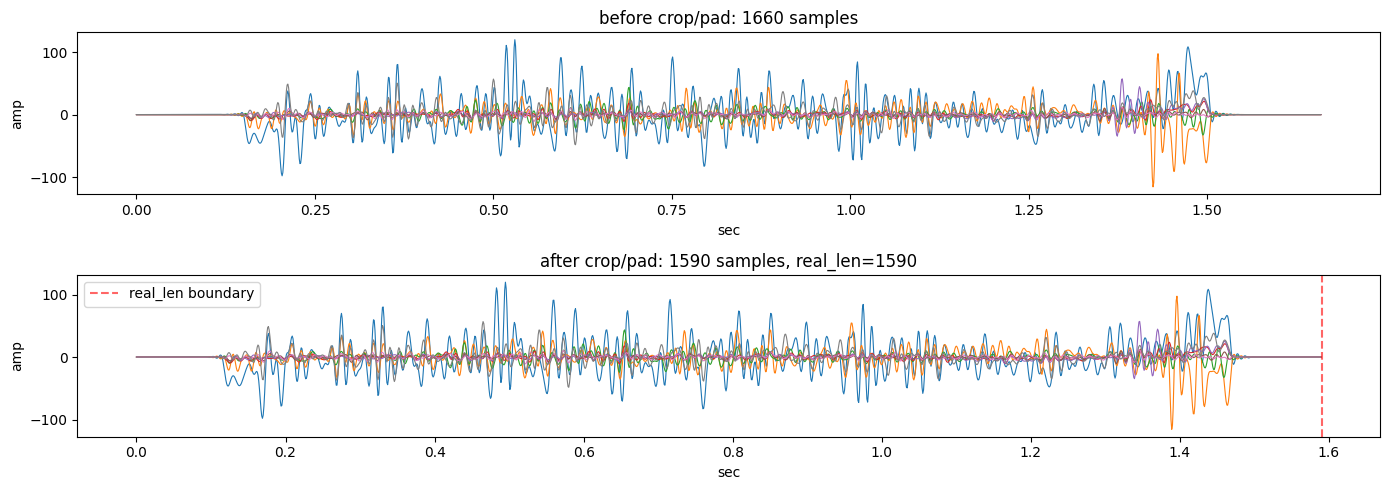

In [9]:
def crop_or_pad_to_target(arr, target_length):
    length = arr.shape[0]
    if length >= target_length:
        start = (length - target_length) // 2
        return arr[start:start + target_length], target_length
    pad_amount = target_length - length
    pad_width = [(0, pad_amount)] + [(0, 0)] * (arr.ndim - 1)
    return np.pad(arr, pad_width, mode="constant"), length


demo_fix, demo_real_len = crop_or_pad_to_target(demo_up, TARGET_LEN)
mode = "center-crop" if len(demo_up) >= TARGET_LEN else "zero-pad"

print(f"before crop/pad: shape={demo_up.shape} ({len(demo_up)} samples @ {FS_DECLARED} Hz)")
print(f"after crop/pad:  shape={demo_fix.shape} ({TARGET_LEN} samples @ {FS_DECLARED} Hz)")
print(f"mode: {mode}")
print(f"real_len for mask: {demo_real_len}")

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharey=True)
axes[0].plot(np.arange(len(demo_up)) / FS_DECLARED, demo_up, linewidth=0.8)
axes[0].set_title(f"before crop/pad: {len(demo_up)} samples")
axes[0].set_xlabel("sec")
axes[0].set_ylabel("amp")
axes[1].plot(np.arange(TARGET_LEN) / FS_DECLARED, demo_fix, linewidth=0.8)
axes[1].axvline(demo_real_len / FS_DECLARED, color="red", ls="--", alpha=0.6, label="real_len boundary")
axes[1].set_title(f"after crop/pad: {TARGET_LEN} samples, real_len={demo_real_len}")
axes[1].set_xlabel("sec")
axes[1].set_ylabel("amp")
axes[1].legend()
plt.tight_layout()


## 7. Full preprocessing pipeline

For every trial we run:

```text
raw @ 200 Hz
  -> bandpass 1.5..99
  -> notch 50 Hz
  -> zero pad buffers
  -> resample_poly x5
  -> crop_or_pad_to_target(TARGET_LEN)
  -> save real_len for mask
```


In [10]:
N = len(X_raw)
X_fix = np.empty((N, TARGET_LEN, 8), dtype=np.float32)
lens_fix = np.empty((N,), dtype=np.int32)

for i, x in enumerate(X_raw):
    x = bandpass(x, fs=FS_ORIG)
    x = notch(x, fs=FS_ORIG)
    x = pad_buffer(x, step_back, step_forward)
    x = resample_poly(x, up=UP, down=1, axis=0)
    x, real_len = crop_or_pad_to_target(x, TARGET_LEN)
    X_fix[i] = x.astype(np.float32)
    lens_fix[i] = int(real_len)
    if (i + 1) % 5000 == 0 or i + 1 == N:
        print(f"processed {i + 1}/{N}")

print(f"\nX_fix.shape = {X_fix.shape}")
print(f"lens_fix stats: min={lens_fix.min()}, mean={lens_fix.mean():.1f}, median={np.median(lens_fix):.0f}, p95={np.percentile(lens_fix, 95):.0f}, max={lens_fix.max()}")
print(f"dtype: {X_fix.dtype}, size: {X_fix.nbytes / 1e6:.1f} MB")


processed 5000/30048
processed 10000/30048
processed 15000/30048
processed 20000/30048
processed 25000/30048
processed 30000/30048
processed 30048/30048

X_fix.shape = (30048, 1590, 8)
lens_fix stats: min=510, mean=1052.3, median=940, p95=1590, max=1590
dtype: float32, size: 1528.8 MB


## 8. Pack into model layout

We trim each subject to the same number of trials and transpose into
`(n_subjects, n_trials, n_channels, n_timepoints)`.
We keep `lens` in the same subject/trial layout.


In [11]:
subjects_unique = np.array(sorted(np.unique(subj_raw)))
n_subj = len(subjects_unique)

idx_by_subj = {s: np.where(subj_raw == s)[0] for s in subjects_unique}
min_trials = min(len(v) for v in idx_by_subj.values())

print("trials per subject before trimming:", {s: len(v) for s, v in idx_by_subj.items()})
print(f"trim to min_trials = {min_trials}")

X = np.empty((n_subj, min_trials, 8, TARGET_LEN), dtype=np.float32)
y = np.empty((n_subj, min_trials), dtype=np.int32)
lens_model = np.empty((n_subj, min_trials), dtype=np.int32)

for i, s in enumerate(subjects_unique):
    sel = idx_by_subj[s][:min_trials]
    X[i] = np.transpose(X_fix[sel], (0, 2, 1))
    y[i] = y_raw[sel]
    lens_model[i] = lens_fix[sel]

subjects = subjects_unique.copy()
sfreq = FS_DECLARED

print("\nFINAL SHAPES")
print(f"X.shape    = {X.shape}")
print(f"y.shape    = {y.shape}")
print(f"lens.shape = {lens_model.shape}")
print(f"subjects   = {subjects}")
print(f"sfreq      = {sfreq}")
print(f"dtype X    = {X.dtype}, size = {X.nbytes / 1e6:.1f} MB")
print(f"lens stats = min={lens_model.min()}, mean={lens_model.mean():.1f}, median={np.median(lens_model):.0f}, p95={np.percentile(lens_model, 95):.0f}, max={lens_model.max()}")

print("\nclass distribution by subject:")
for i, s in enumerate(subjects):
    u, c = np.unique(y[i], return_counts=True)
    print(f"  {s}: {dict(zip(u.tolist(), c.tolist()))}")


trials per subject before trimming: {np.str_('S01'): 10027, np.str_('S02'): 10021, np.str_('S03'): 10000}
trim to min_trials = 10000

FINAL SHAPES
X.shape    = (3, 10000, 8, 1590)
y.shape    = (3, 10000)
lens.shape = (3, 10000)
subjects   = ['S01' 'S02' 'S03']
sfreq      = 1000
dtype X    = float32, size = 1526.4 MB
lens stats = min=510, mean=1052.5, median=940, p95=1590, max=1590

class distribution by subject:
  S01: {0: 1002, 1: 1001, 2: 1008, 3: 1003, 4: 1002, 5: 1002, 6: 1002, 7: 1003, 8: 1002, 9: 975}
  S02: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1020, 7: 1000, 8: 1000, 9: 980}
  S03: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


## 9. Save

Save compressed `.npz` with `lens` included.


In [12]:
out_path = (DATA_ROOT / 'datasets' / 'hcmyo_preprocessed.npz').resolve()
out_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(out_path, X=X, y=y, subjects=subjects, sfreq=sfreq, lens=lens_model)
print(f"saved: {out_path}")
print(f"size:  {out_path.stat().st_size / 1e6:.1f} MB")


saved: code_bobr_678/data/datasets/hcmyo_preprocessed.npz
size:  792.8 MB
